In [1]:
import pandas as pd

file_path = r"D:\Mobina\Brain.csv"
df = pd.read_csv(file_path)
df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,...,9.979005,9.926470,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,...,11.924749,11.215930,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416
2,836,ependymoma,13.068179,8.573674,8.647684,9.613002,4.396581,7.813101,6.007746,7.178156,...,12.154405,11.532460,13.764593,13.477800,5.303565,5.052184,4.005343,3.595382,4.563494,4.668827
3,837,ependymoma,12.456040,9.098977,6.628784,8.517677,4.154847,8.361843,6.596064,6.347285,...,11.969072,11.288801,13.600828,13.379029,4.953429,4.708371,3.892318,3.759429,4.748381,4.521275
4,838,ependymoma,12.699958,8.800721,11.556188,9.166309,4.165891,7.923826,6.212754,6.866387,...,11.411701,11.169317,13.751442,13.803646,4.892677,4.773806,3.796856,3.577544,4.504385,4.541450


# PCA

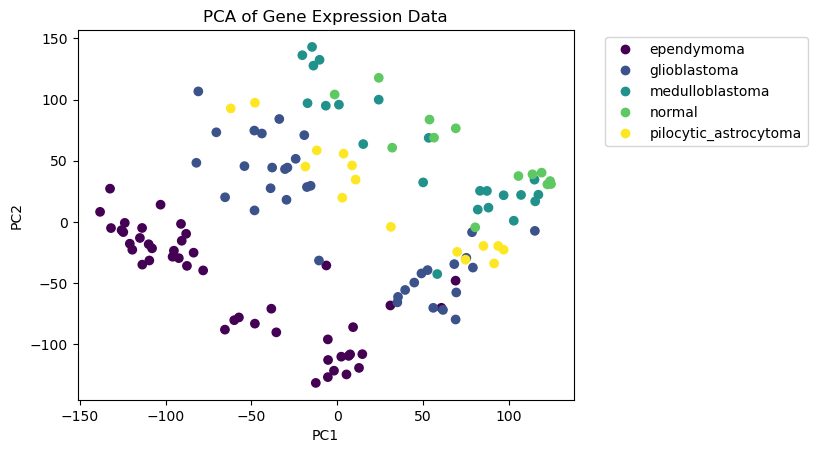

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# separate features and labels
X = df.drop(columns=['type'])
y = df['type']

# encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded)

# get colors from scatter
colors = scatter.cmap(scatter.norm(y_encoded))

# create legend with matching colors
handles = []
for i, label in enumerate(le.classes_):
    handles.append(
        plt.Line2D([], [], 
                   marker='o', 
                   linestyle='', 
                   color=colors[y_encoded == i][0], 
                   label=label)
    )

plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gene Expression Data")
plt.show()

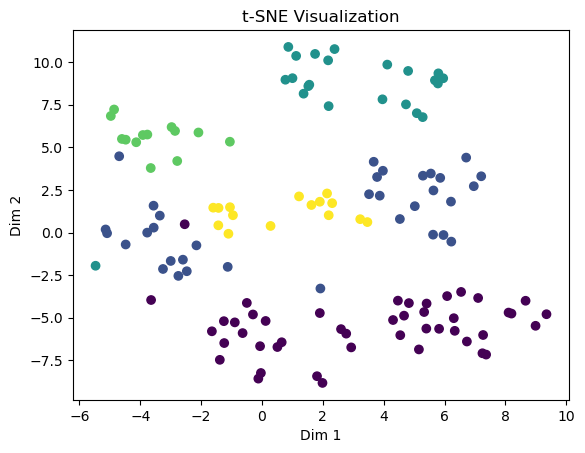

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_encoded)
plt.title("t-SNE Visualization")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

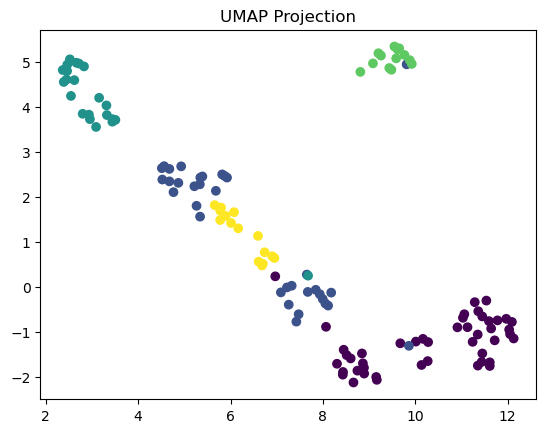

In [4]:
import umap.umap_ as umap

reducer = umap.UMAP()
X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_encoded)
plt.title("UMAP Projection")
plt.show()

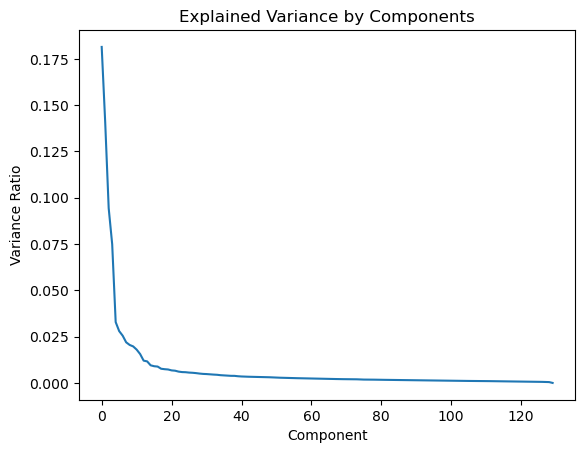

In [5]:
pca = PCA().fit(X)

plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by Components")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

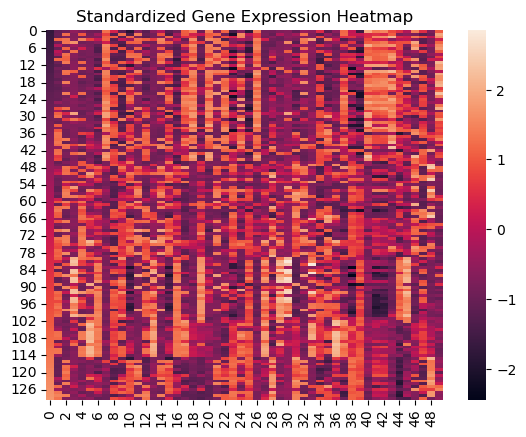

In [6]:
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# select top variable genes
X_small = X.loc[:, X.var().nlargest(50).index]

# standardize (column-wise)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_small)

sns.heatmap(X_scaled)
plt.title("Standardized Gene Expression Heatmap")
plt.show()

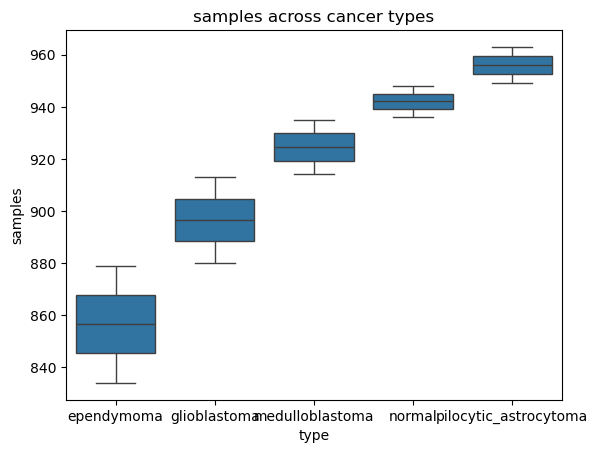

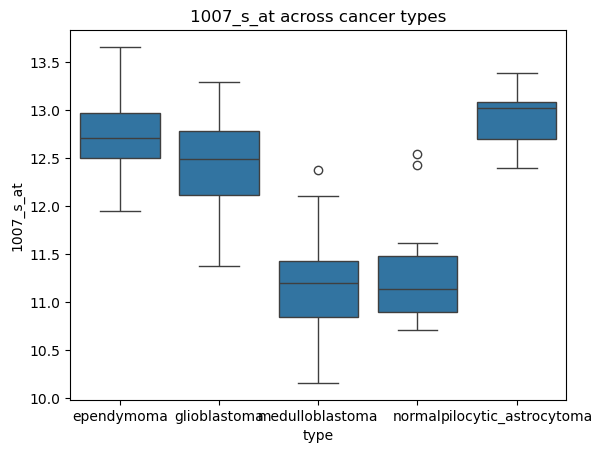

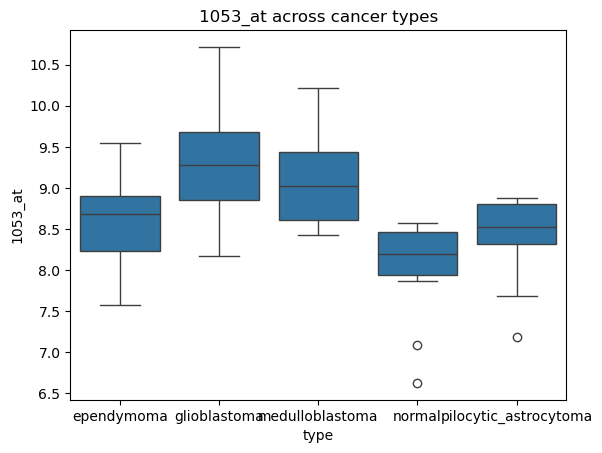

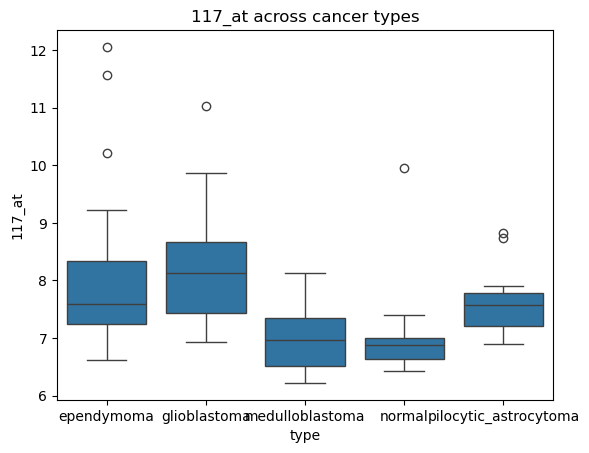

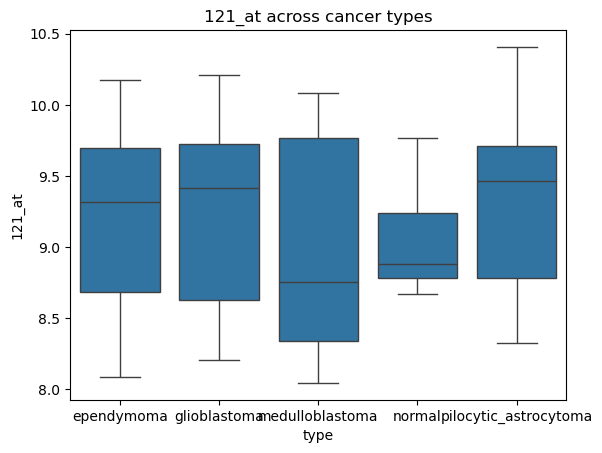

In [7]:
import seaborn as sns

genes = X.columns[:5]  # or top variance genes

for g in genes:
    sns.boxplot(x=y, y=X[g])
    plt.title(f"{g} across cancer types")
    plt.show()

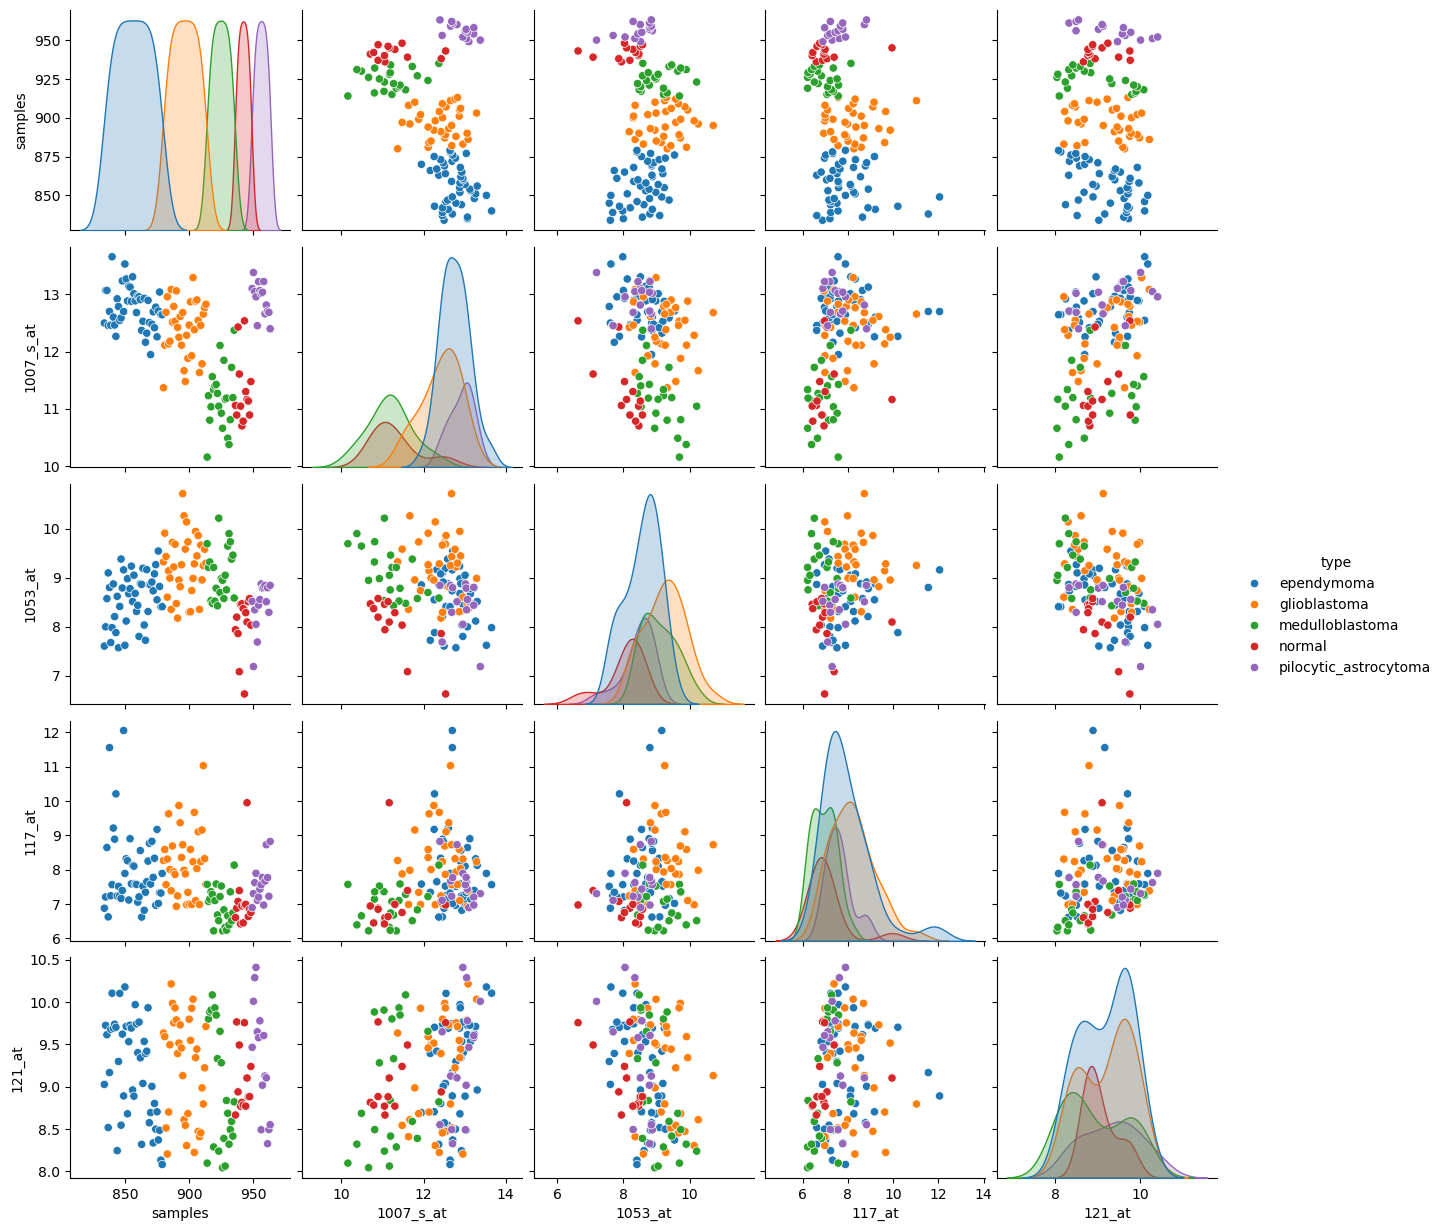

In [8]:
import seaborn as sns

df_small = X.iloc[:, :5].copy()
df_small['type'] = y

sns.pairplot(df_small, hue='type')

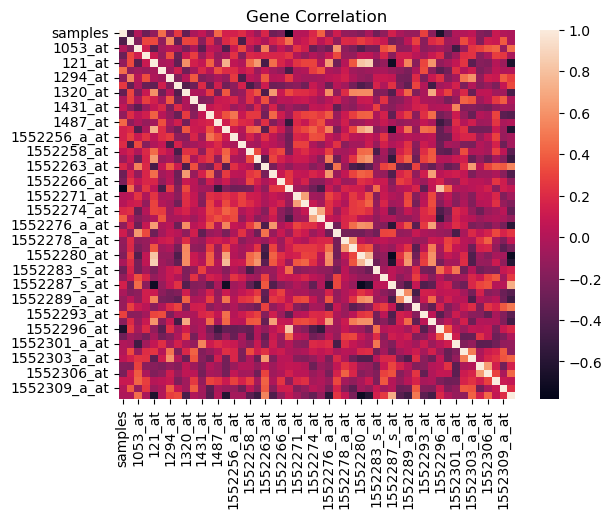

In [9]:
corr = X.iloc[:, :50].corr()

sns.heatmap(corr)
plt.title("Gene Correlation")
plt.show()

# Autoencoder

In [10]:
# Pre-processing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# split
X = df.drop(columns=['type'])
y = df['type']

# reduce features (critical!)
X = X.loc[:, X.var().nlargest(1000).index]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA baseline
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [11]:
# AE
import torch
import torch.nn as nn
import torch.optim as optim

# convert to tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# model
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 2)   # latent space (2D)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

model = Autoencoder(X_scaled.shape[1])

# training
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()
    X_hat, z = model(X_tensor)
    loss = criterion(X_hat, X_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.0088
Epoch 10, Loss: 0.8941
Epoch 20, Loss: 0.7021
Epoch 30, Loss: 0.5844
Epoch 40, Loss: 0.5067


In [12]:
# Extract latent space
with torch.no_grad():
    _, Z = model(X_tensor)

X_ae = Z.numpy()

# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

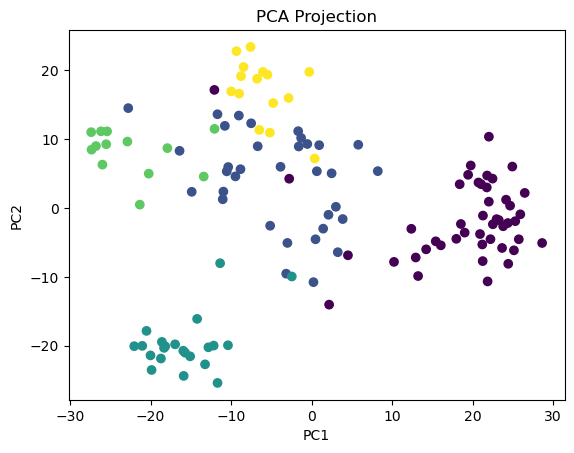

In [13]:
# PCA Plot
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

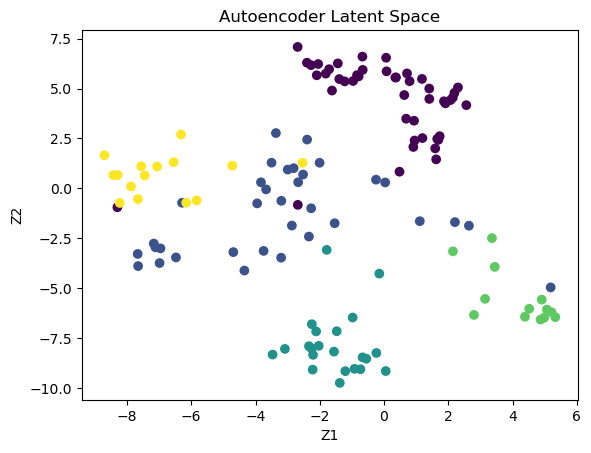

In [14]:
# AE Plot
plt.scatter(X_ae[:, 0], X_ae[:, 1], c=y_encoded)
plt.title("Autoencoder Latent Space")
plt.xlabel("Z1")
plt.ylabel("Z2")
plt.show()

# Reconstruction and Forecast

Epoch 0, Loss: 1.0095
Epoch 20, Loss: 0.5048
Epoch 40, Loss: 0.3826
Epoch 60, Loss: 0.3215
Epoch 80, Loss: 0.2753
Epoch 100, Loss: 0.2446
Epoch 120, Loss: 0.2122
Epoch 140, Loss: 0.1817
Epoch 160, Loss: 0.1577
Epoch 180, Loss: 0.1359

=== Classification Accuracy ===
PCA Accuracy: 0.8461538461538461
AE Accuracy: 0.9230769230769231

=== Reconstruction Error ===
PCA MSE: 0.4501989276851766
AE MSE: 0.4075746260665156


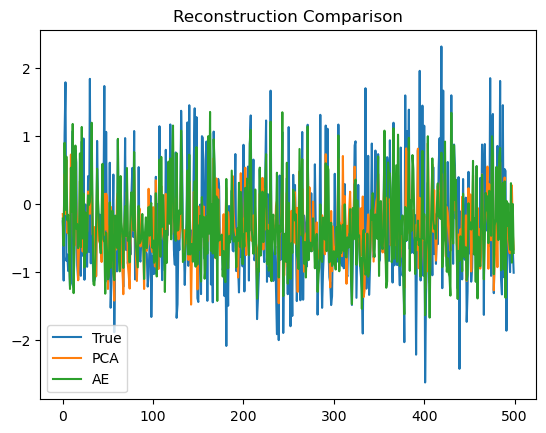

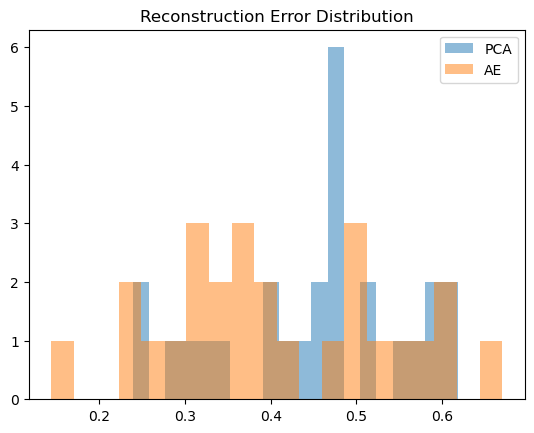

In [15]:
# =====================================
# 1. Imports
# =====================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import RandomForestClassifier

import random
random.seed(1000)


# =====================================
# 2. Data Preprocessing
# =====================================
# Split features and labels
X = df.drop(columns=['type'])
y = df['type']

# Reduce dimensionality (important!)
X = X.loc[:, X.var().nlargest(500).index]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)


# =====================================
# 3. PCA
# =====================================
latent_dim = 5 

pca = PCA(n_components=latent_dim)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Reconstruction
X_test_pca_recon = pca.inverse_transform(X_test_pca)


# =====================================
# 4. Autoencoder Model
# =====================================
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Initialize model
model = Autoencoder(input_dim=X_train.shape[1], latent_dim=latent_dim)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()


# =====================================
# 5. Train Autoencoder
# =====================================
epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()

    X_hat, _ = model(X_train_tensor)
    loss = criterion(X_hat, X_train_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


# =====================================
# 6. Extract Latent + Reconstruction
# =====================================
with torch.no_grad():
    _, Z_train = model(X_train_tensor)
    X_test_recon, Z_test = model(X_test_tensor)

X_train_ae = Z_train.numpy()
X_test_ae = Z_test.numpy()
X_test_ae_recon = X_test_recon.numpy()


# =====================================
# 7. Classification (PCA vs AE)
# =====================================
clf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)

clf_ae = RandomForestClassifier(n_estimators=100, random_state=42)
clf_ae.fit(X_train_ae, y_train)
y_pred_ae = clf_ae.predict(X_test_ae)

print("\n=== Classification Accuracy ===")
print("PCA Accuracy:", accuracy_score(y_test, y_pred_pca))
print("AE Accuracy:", accuracy_score(y_test, y_pred_ae))


# =====================================
# 8. Reconstruction Error
# =====================================
pca_mse = mean_squared_error(X_test, X_test_pca_recon)
ae_mse = mean_squared_error(X_test, X_test_ae_recon)

print("\n=== Reconstruction Error ===")
print("PCA MSE:", pca_mse)
print("AE MSE:", ae_mse)


# =====================================
# 9. Reconstruction Visualization
# =====================================
i = 0  # sample index

plt.figure()
plt.plot(X_test[i], label="True")
plt.plot(X_test_pca_recon[i], label="PCA")
plt.plot(X_test_ae_recon[i], label="AE")
plt.legend()
plt.title("Reconstruction Comparison")
plt.show()


# =====================================
# 10. Error Distribution
# =====================================
pca_errors = np.mean((X_test - X_test_pca_recon)**2, axis=1)
ae_errors = np.mean((X_test - X_test_ae_recon)**2, axis=1)

plt.figure()
plt.hist(pca_errors, bins=20, alpha=0.5, label="PCA")
plt.hist(ae_errors, bins=20, alpha=0.5, label="AE")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()

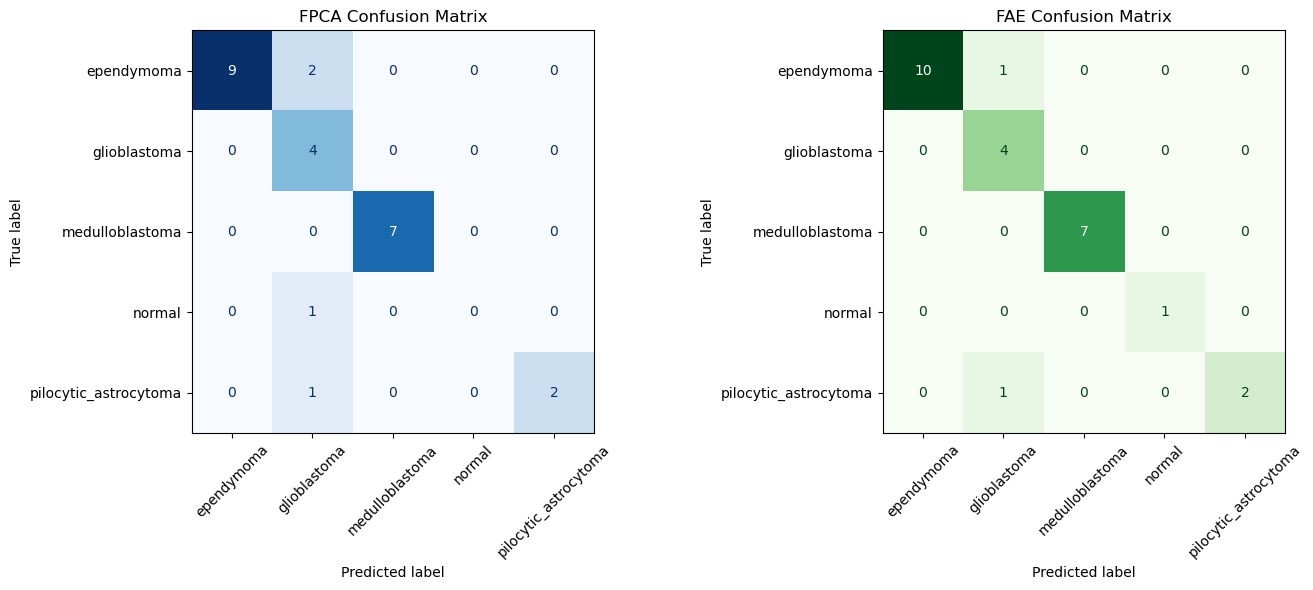

In [ ]:
# =====================================
# 11. Side-by-Side Confusion Matrices
# =====================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrices
cm_pca = confusion_matrix(y_test, y_pred_pca)
cm_ae = confusion_matrix(y_test, y_pred_ae)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=le.classes_)
disp_pca.plot(ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
axes[0].set_title("PCA Confusion Matrix")

disp_ae = ConfusionMatrixDisplay(confusion_matrix=cm_ae, display_labels=le.classes_)
disp_ae.plot(ax=axes[1], cmap="Greens", xticks_rotation=45, colorbar=False)
axes[1].set_title("AE Confusion Matrix")

plt.tight_layout()
plt.show()

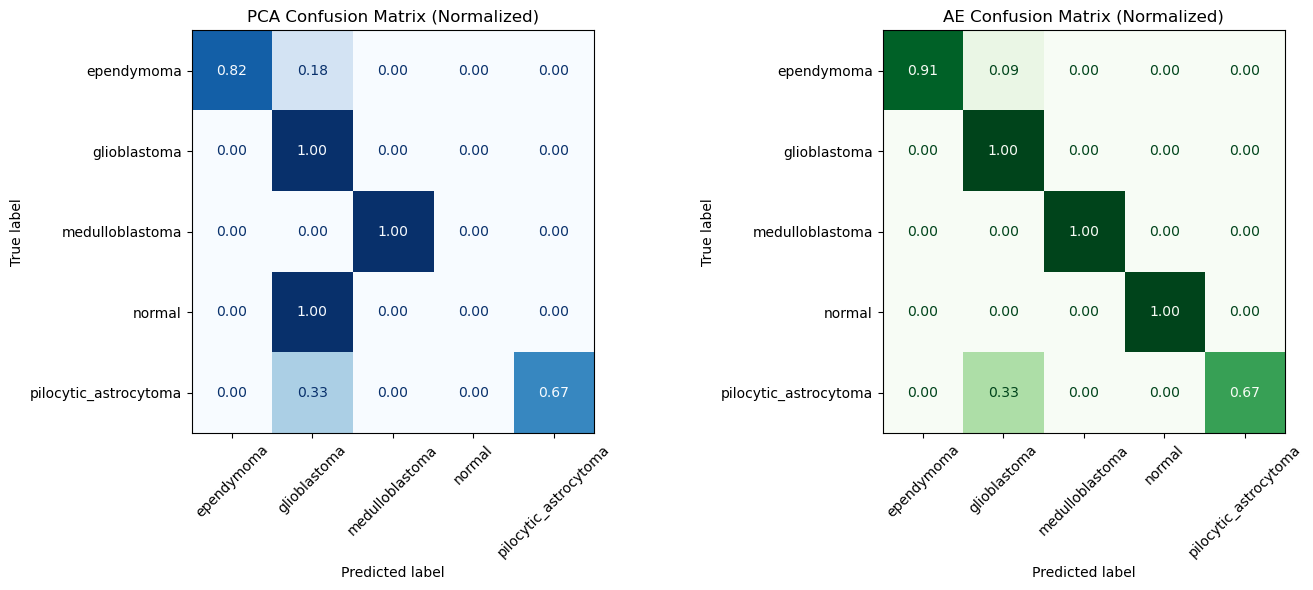

In [19]:
cm_pca_norm = confusion_matrix(y_test, y_pred_pca, normalize="true")
cm_ae_norm = confusion_matrix(y_test, y_pred_ae, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(cm_pca_norm, display_labels=le.classes_).plot(
    ax=axes[0], cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False
)
axes[0].set_title("PCA Confusion Matrix (Normalized)")

ConfusionMatrixDisplay(cm_ae_norm, display_labels=le.classes_).plot(
    ax=axes[1], cmap="Greens", xticks_rotation=45, values_format=".2f", colorbar=False
)
axes[1].set_title("AE Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()

In [28]:
X_original = X_test
X_fpca     = X_test_pca_recon
X_fae      = X_test_ae_recon
y          = y_test

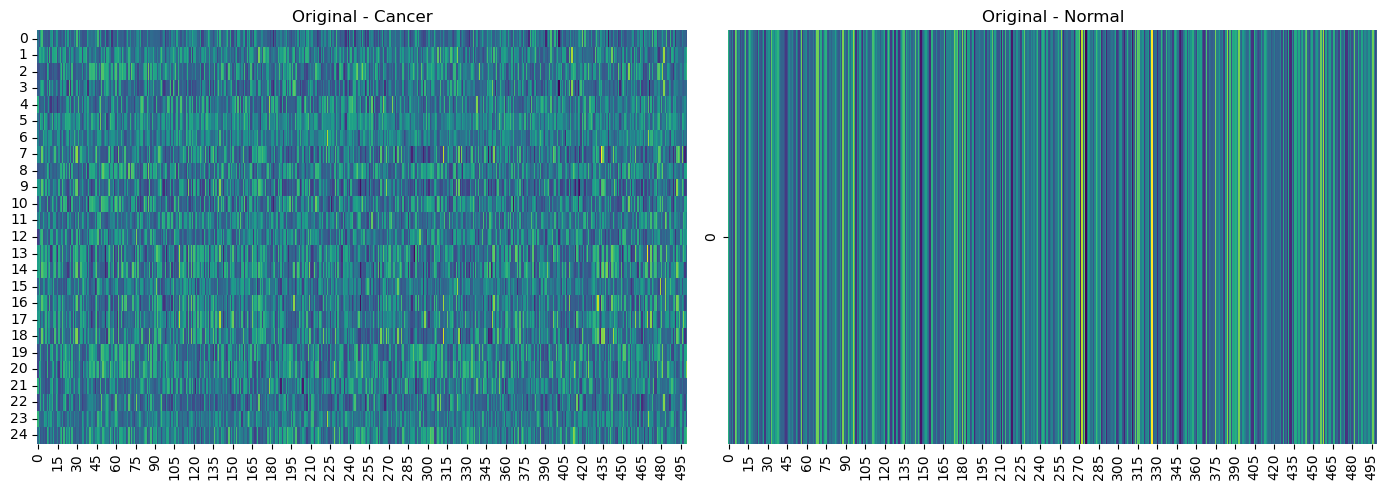

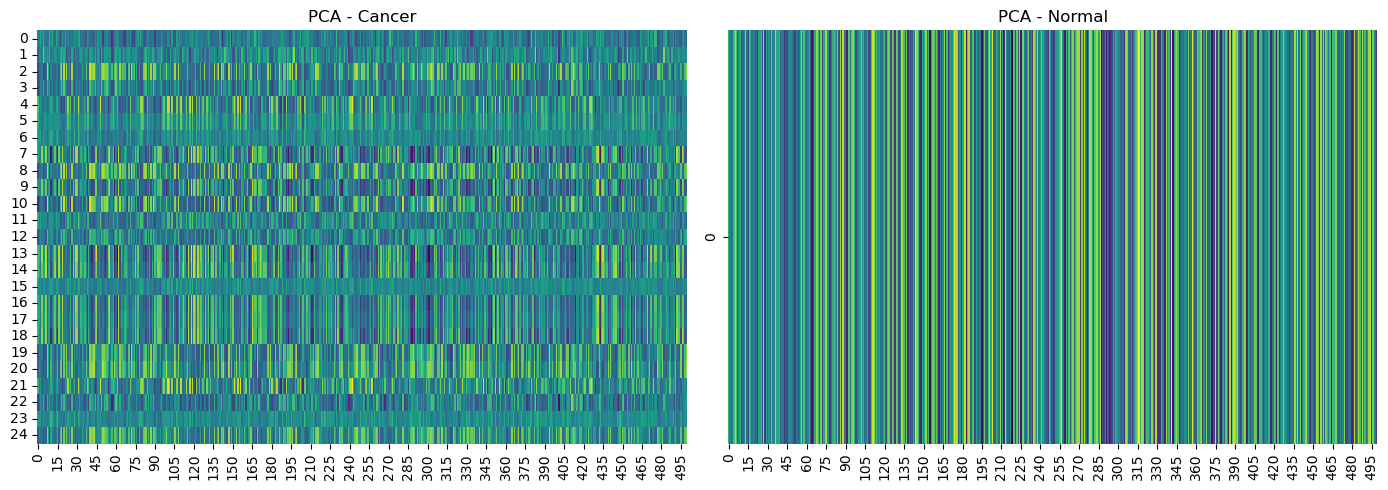

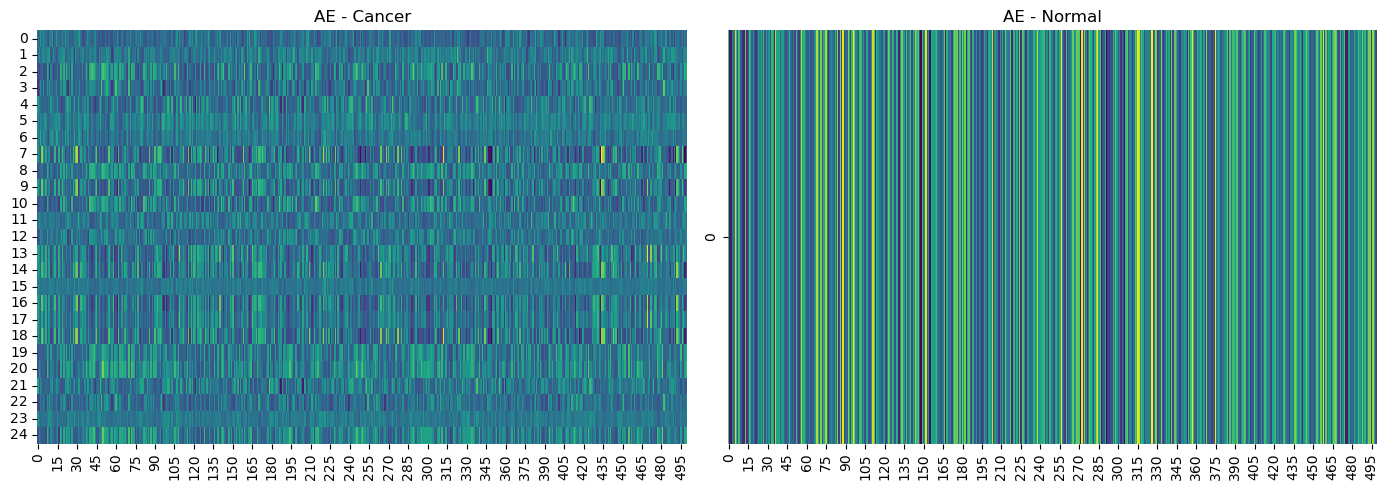

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_group_heatmaps(X, y, title):
    cancer_idx = y != le.transform(['normal'])[0]
    normal_idx = y == le.transform(['normal'])[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(X[cancer_idx][:50], ax=axes[0], cmap='viridis', cbar=False)
    axes[0].set_title(f'{title} - Cancer')

    sns.heatmap(X[normal_idx][:50], ax=axes[1], cmap='viridis', cbar=False)
    axes[1].set_title(f'{title} - Normal')

    plt.tight_layout()
    plt.show()

plot_group_heatmaps(X_original, y, "Original")
plot_group_heatmaps(X_fpca, y, "PCA")
plot_group_heatmaps(X_fae, y, "AE")

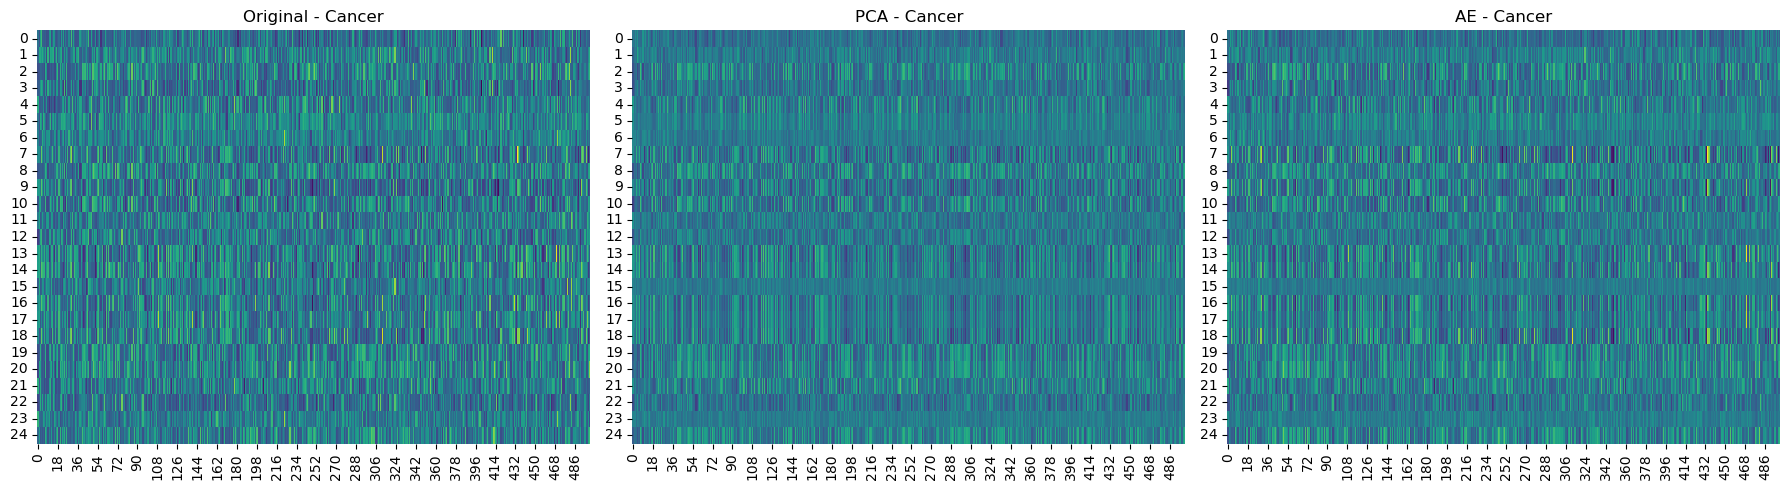

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_cancer_only(X_orig, X_fpca, X_fae, y, le):
    
    normal_label = le.transform(['normal'])[0]
    cancer_idx = np.where(y != normal_label)[0][:40]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Optional: consistent color scale (VERY important)
    vmin = min(X_orig.min(), X_fpca.min(), X_fae.min())
    vmax = max(X_orig.max(), X_fpca.max(), X_fae.max())

    # Original
    sns.heatmap(X_orig[cancer_idx], ax=axes[0], cmap='viridis',
                vmin=vmin, vmax=vmax, cbar=False)
    axes[0].set_title("Original - Cancer")

    # PCA
    sns.heatmap(X_fpca[cancer_idx], ax=axes[1], cmap='viridis',
                vmin=vmin, vmax=vmax, cbar=False)
    axes[1].set_title("PCA - Cancer")

    # AE
    sns.heatmap(X_fae[cancer_idx], ax=axes[2], cmap='viridis',
                vmin=vmin, vmax=vmax, cbar=False)
    axes[2].set_title("AE - Cancer")

    plt.tight_layout()
    plt.show()

plot_cancer_only(X_original, X_fpca, X_fae, y, le)

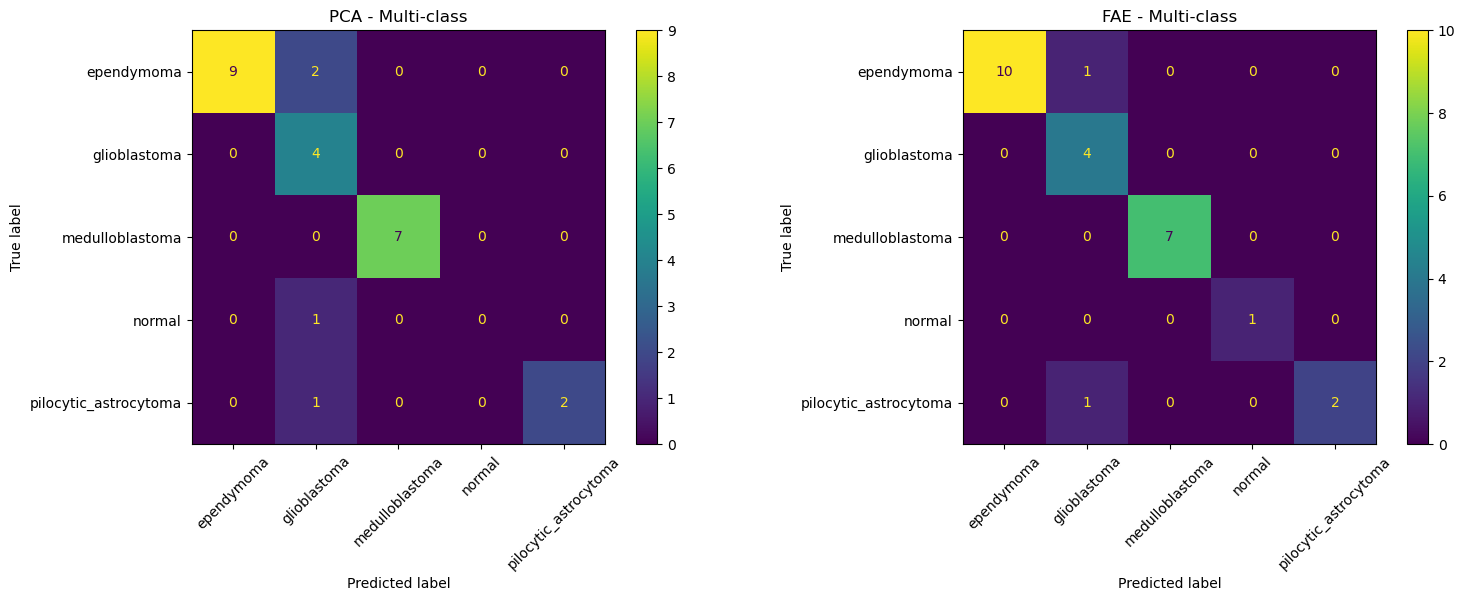

In [43]:
X_original = X_test
X_fpca     = X_test_pca_recon
X_fae      = X_test_ae_recon
y_true     = y_test

y_pred_pca_full = y_pred_pca
y_pred_ae_full  = y_pred_ae


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16,6))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_pca_full),
    display_labels=le.classes_
).plot(ax=axes[0], xticks_rotation=45)
axes[0].set_title("PCA - Multi-class")

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_ae_full),
    display_labels=le.classes_
).plot(ax=axes[1], xticks_rotation=45)
axes[1].set_title("FAE - Multi-class")

plt.tight_layout()
plt.show()

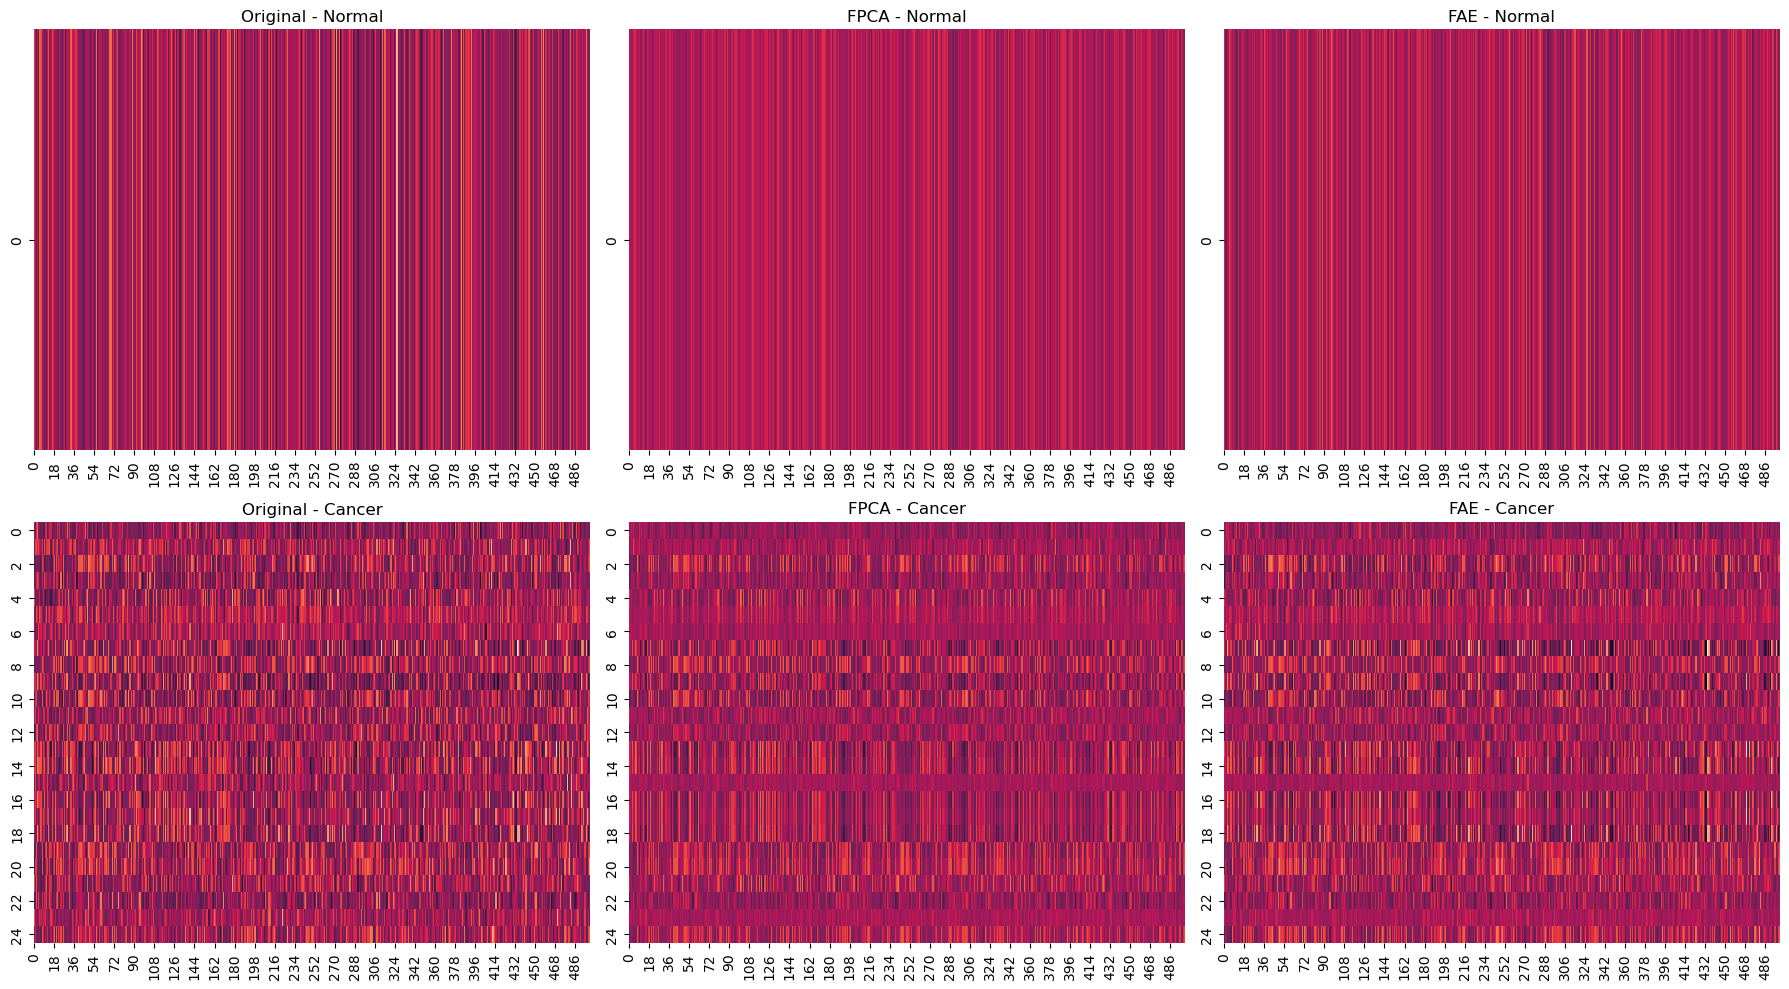

In [45]:
import seaborn as sns

def plot_comparison(X_orig, X_fpca, X_fae, y, le):
    normal_label = le.transform(['normal'])[0]

    normal_idx = np.where(y == normal_label)[0][:40]
    cancer_idx = np.where(y != normal_label)[0][:40]

    vmin = min(X_orig.min(), X_fpca.min(), X_fae.min())
    vmax = max(X_orig.max(), X_fpca.max(), X_fae.max())

    fig, axes = plt.subplots(2, 3, figsize=(18,10))

    # Normal
    sns.heatmap(X_orig[normal_idx], ax=axes[0,0], vmin=vmin, vmax=vmax, cbar=False)
    axes[0,0].set_title("Original - Normal")

    sns.heatmap(X_fpca[normal_idx], ax=axes[0,1], vmin=vmin, vmax=vmax, cbar=False)
    axes[0,1].set_title("FPCA - Normal")

    sns.heatmap(X_fae[normal_idx], ax=axes[0,2], vmin=vmin, vmax=vmax, cbar=False)
    axes[0,2].set_title("FAE - Normal")

    # Cancer
    sns.heatmap(X_orig[cancer_idx], ax=axes[1,0], vmin=vmin, vmax=vmax, cbar=False)
    axes[1,0].set_title("Original - Cancer")

    sns.heatmap(X_fpca[cancer_idx], ax=axes[1,1], vmin=vmin, vmax=vmax, cbar=False)
    axes[1,1].set_title("FPCA - Cancer")

    sns.heatmap(X_fae[cancer_idx], ax=axes[1,2], vmin=vmin, vmax=vmax, cbar=False)
    axes[1,2].set_title("FAE - Cancer")

    plt.tight_layout()
    plt.show()


plot_comparison(X_original, X_fpca, X_fae, y_true, le)

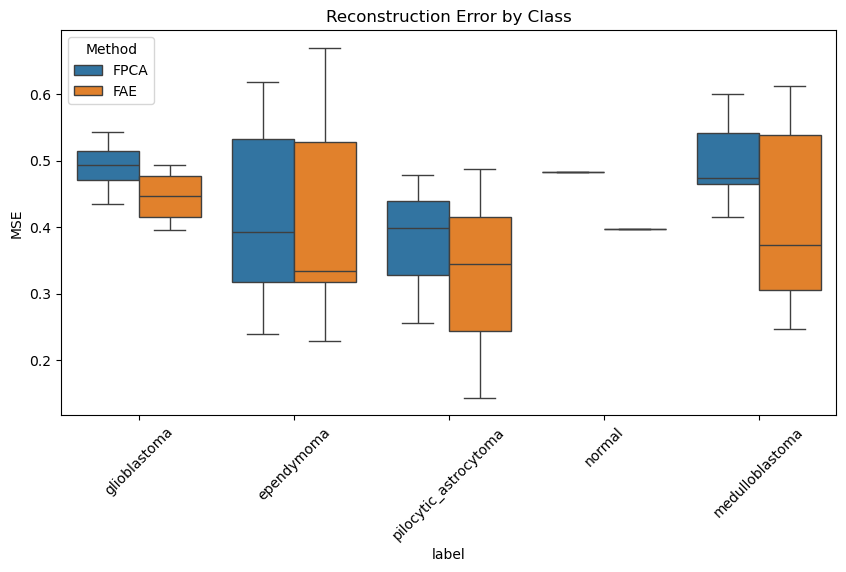

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fpca_err = np.mean((X_test - X_test_pca_recon)**2, axis=1)
ae_err   = np.mean((X_test - X_test_ae_recon)**2, axis=1)

df_err = pd.DataFrame({
    "FPCA": fpca_err,
    "FAE": ae_err,
    "label": le.inverse_transform(y_test)
})

df_melt = df_err.melt(id_vars="label", var_name="Method", value_name="MSE")

plt.figure(figsize=(10,5))
sns.boxplot(data=df_melt, x="label", y="MSE", hue="Method")
plt.title("Reconstruction Error by Class")
plt.xticks(rotation=45)
plt.show()

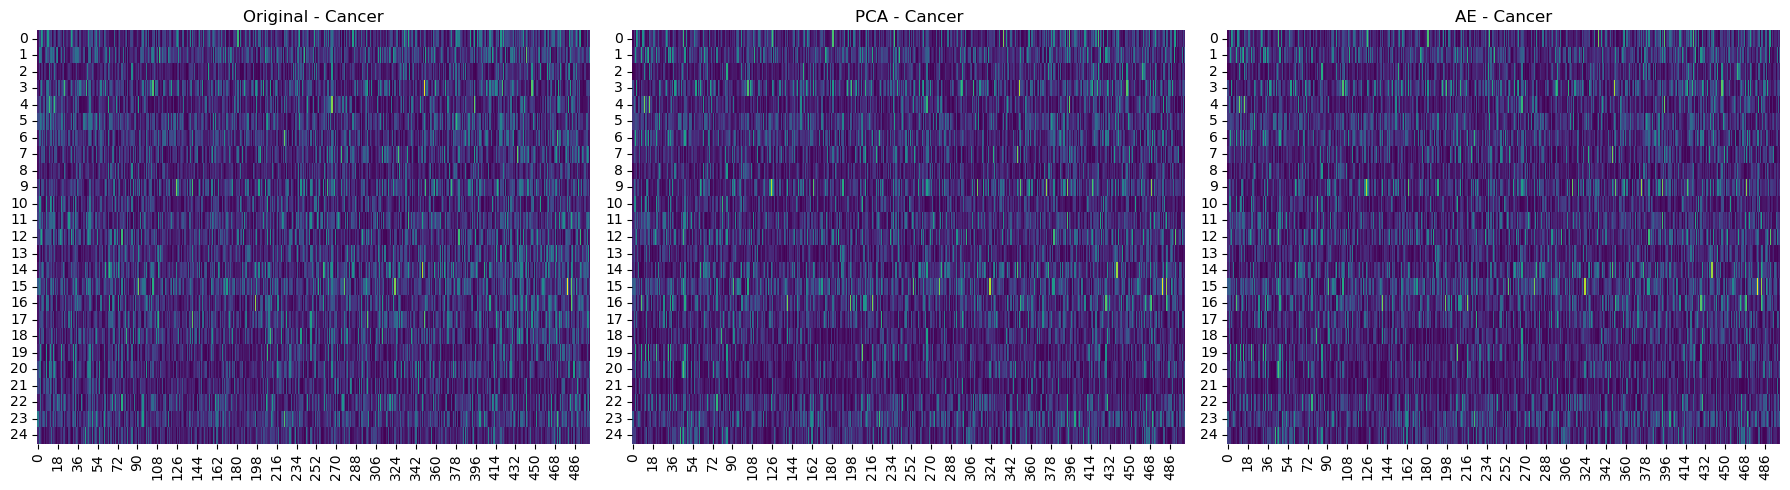

In [54]:
fpca_error = np.abs(X_test - X_test_pca_recon)
ae_error   = np.abs(X_test - X_test_ae_recon)

plot_cancer_only(fpca_error, ae_error, ae_error, y_test, le)

Autoencoder reconstructs cancer gene expression patterns more accurately at a local level, while PCA produces overly smoothed reconstructions that fail to capture fine-grained structure.

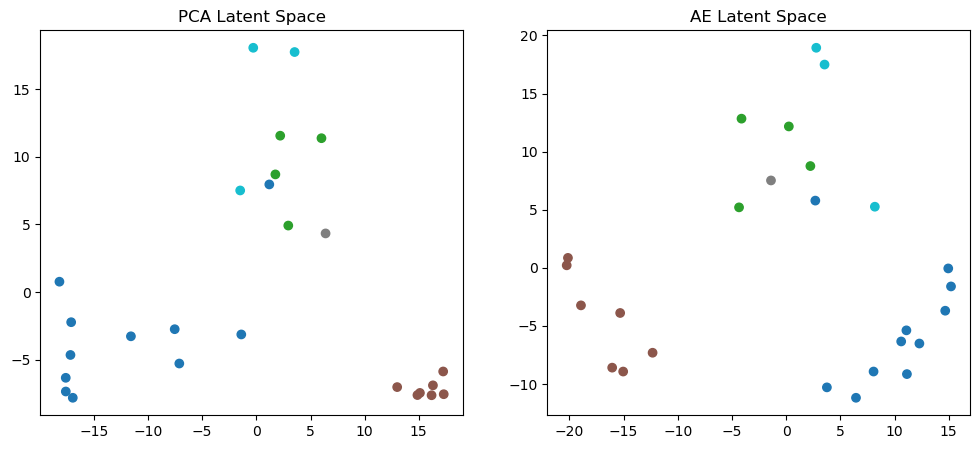

In [55]:
from sklearn.decomposition import PCA as PCA2

# Reduce to 2D for visualization
pca_vis = PCA2(n_components=2)
Z_pca_2d = pca_vis.fit_transform(X_test_pca)

Z_ae_2d = pca_vis.fit_transform(X_test_ae)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(Z_pca_2d[:,0], Z_pca_2d[:,1], c=y_test, cmap='tab10')
plt.title("PCA Latent Space")

plt.subplot(1,2,2)
plt.scatter(Z_ae_2d[:,0], Z_ae_2d[:,1], c=y_test, cmap='tab10')
plt.title("AE Latent Space")

plt.show()

The autoencoder learns a more discriminative latent representation, improving class separability compared to PCA.

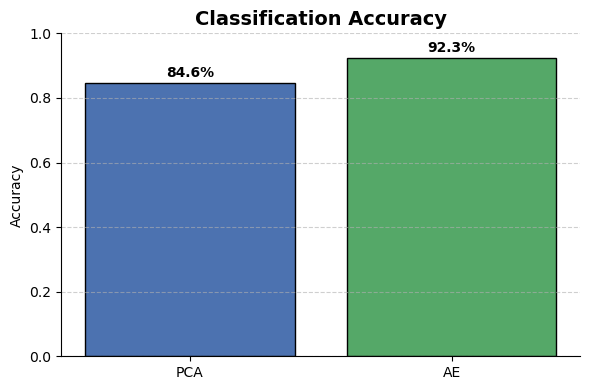

In [61]:
import matplotlib.pyplot as plt

# Data
labels = ["PCA", "AE"]
values = [
    accuracy_score(y_test, y_pred_pca),
    accuracy_score(y_test, y_pred_ae)
]

# Colors
colors = ["#4C72B0", "#55A868"]  # blue & green

# Create figure
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=colors, edgecolor='black')

# Add data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height*100:.1f}%", 
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Styling
plt.title("Classification Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Remove top/right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()